# Stage 9 - MRL Eye Open/Closed CNN Baselines

This notebook trains the **MRL Eye eye-state specialist**. It is not a full drowsiness classifier.

The module outputs per-frame probabilities:

- `p_eye_closed`
- `p_eye_open`

These outputs are intended for later temporal smoothing or PERCLOS-like fusion with the completed YawDD mouth/yawn module.

## Notebook Notes

- Use a GPU runtime for full training.
- This notebook uses the existing Stage 8 subject-level split manifest.
- It does not rebuild the dataset and does not create image-level random splits.
- The `DATA_ROOT` variable controls path remapping when the manifest contains local absolute paths from another machine.

In [1]:
# 1. Runtime and repository configuration
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/Drowsiness_Detection_Colab")
DRIVE_PROJECT_ROOT = DRIVE_ROOT

REPO_URL = "https://github.com/JohnCoffey-commits/Drowsiness-Detection.git"
REPO_BRANCH = "main"
REPO_DIR = DRIVE_ROOT / "repo"

DRIVE_DATA_DIR = DRIVE_ROOT / "data"
DRIVE_ZIP = DRIVE_DATA_DIR / "mrlEyes_2018_01.zip"

LOCAL_DATA_DIR = Path("/content/data")
LOCAL_ZIP = LOCAL_DATA_DIR / "mrlEyes_2018_01.zip"

# The manifest path is relative to the repo after os.chdir(REPO_DIR).
MANIFEST = Path("artifacts/mappings/mrl_eye_trainable_with_split.csv")
OUTPUT_DIR = DRIVE_ROOT / "outputs" / "mrl_eye"
DEBUG_OUTPUT_DIR = DRIVE_ROOT / "outputs" / "mrl_eye_debug"

FORCE_RECLONE_REPO = False

MODELS = ["resnet18", "mobilenet_v2", "efficientnet_b0"]
EPOCHS = 10
BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_WORKERS = 2
SEED = 42


In [2]:
# 2. Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")
print("Drive project root:", DRIVE_PROJECT_ROOT)

Mounted at /content/drive
Drive project root: /content/drive/MyDrive/Drowsiness_Detection_Colab


## Prepare MRL Eye dataset on local Colab disk

The MRL Eye zip stays in Google Drive at `data/mrlEyes_2018_01.zip`.

For each Colab runtime, the notebook copies the zip to `/content/data`, extracts the dataset locally, and uses the local extracted folder as `DATA_ROOT`. This is faster and avoids relying on a partial Google Drive extraction. `/content` is temporary and will be lost after the runtime disconnects.

Training outputs are still saved back to Google Drive under `outputs/mrl_eye/`.


In [3]:
# 3. Copy MRL Eye zip from Google Drive to local Colab disk
from pathlib import Path
import shutil
import time
import zipfile

DRIVE_ROOT = Path("/content/drive/MyDrive/Drowsiness_Detection_Colab")
DRIVE_PROJECT_ROOT = DRIVE_ROOT
DRIVE_DATA_DIR = DRIVE_ROOT / "data"
DRIVE_ZIP = DRIVE_DATA_DIR / "mrlEyes_2018_01.zip"

LOCAL_DATA_DIR = Path("/content/data")
LOCAL_ZIP = LOCAL_DATA_DIR / "mrlEyes_2018_01.zip"

OUTPUT_DIR = DRIVE_ROOT / "outputs" / "mrl_eye"
DEBUG_OUTPUT_DIR = DRIVE_ROOT / "outputs" / "mrl_eye_debug"

LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEBUG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DRIVE_ZIP:", DRIVE_ZIP)
print("DRIVE_ZIP exists:", DRIVE_ZIP.exists())

if not DRIVE_ZIP.exists():
    raise FileNotFoundError(f"MRL Eye zip not found in Google Drive: {DRIVE_ZIP}")

if not LOCAL_ZIP.exists():
    print("Copying MRL Eye zip from Google Drive to local /content/data ...")
    start = time.time()
    shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
    print(f"Copy complete in {(time.time() - start) / 60:.2f} minutes")
else:
    print("Local zip already exists. Skipping copy.")

print("LOCAL_ZIP:", LOCAL_ZIP)
print("LOCAL_ZIP size GB:", LOCAL_ZIP.stat().st_size / 1024**3)

with zipfile.ZipFile(LOCAL_ZIP, "r") as z:
    names = z.namelist()
    pngs = [name for name in names if name.lower().endswith(".png")]
    print("PNG files inside zip:", len(pngs))
    s0011_pngs = [name for name in pngs if "/s0011/" in name or name.startswith("s0011/")]
    print("s0011 PNG files inside zip:", len(s0011_pngs))


DRIVE_ZIP: /content/drive/MyDrive/Drowsiness_Detection_Colab/data/mrlEyes_2018_01.zip
DRIVE_ZIP exists: True
Copying MRL Eye zip from Google Drive to local /content/data ...
Copy complete in 0.13 minutes
LOCAL_ZIP: /content/data/mrlEyes_2018_01.zip
LOCAL_ZIP size GB: 0.35644947830587626
PNG files inside zip: 169796
s0011 PNG files inside zip: 3296


In [4]:
# 4. Extract locally and validate completeness
EXPECTED_TOTAL_IMAGES = 84898


def find_mrl_eye_root(base_dir: Path):
    candidates = [
        base_dir / "mrlEyes_2018_01",
        base_dir / "dataset" / "mrlEyes_2018_01",
        base_dir / "mrlEyes_2018_01" / "mrlEyes_2018_01",
    ]
    for candidate in candidates:
        if (
            (candidate / "annotation.txt").exists()
            and (candidate / "s0001").exists()
            and (candidate / "s0037").exists()
        ):
            return candidate
    return None


def count_pngs(path: Path) -> int:
    if path is None or not path.exists():
        return 0
    return sum(1 for _ in path.rglob("*.png"))


def subject_png_count(root: Path, subject: str) -> int:
    if root is None:
        return 0
    folder = root / subject
    if not folder.exists():
        return 0
    return sum(1 for _ in folder.glob("*.png"))


def is_complete_mrl_eye_root(root: Path) -> bool:
    if root is None or not root.exists():
        print("MRL Eye root not found.")
        return False
    total_png = count_pngs(root)
    checks = {
        "annotation.txt": (root / "annotation.txt").exists(),
        "s0001_pngs": subject_png_count(root, "s0001"),
        "s0011_pngs": subject_png_count(root, "s0011"),
        "s0037_pngs": subject_png_count(root, "s0037"),
        "total_png": total_png,
    }
    print("MRL Eye completeness checks:", checks)
    return (
        checks["annotation.txt"]
        and checks["s0001_pngs"] > 0
        and checks["s0011_pngs"] > 0
        and checks["s0037_pngs"] > 0
        and checks["total_png"] == EXPECTED_TOTAL_IMAGES
    )


DATA_ROOT = find_mrl_eye_root(LOCAL_DATA_DIR)

if not is_complete_mrl_eye_root(DATA_ROOT):
    print("Local MRL Eye extraction is missing or incomplete. Re-extracting locally...")
    for candidate in [
        LOCAL_DATA_DIR / "mrlEyes_2018_01",
        LOCAL_DATA_DIR / "dataset",
    ]:
        if candidate.exists():
            print(f"Removing incomplete local folder only: {candidate}")
            shutil.rmtree(candidate)

    start = time.time()
    with zipfile.ZipFile(LOCAL_ZIP, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATA_DIR)
    print(f"Extraction complete in {(time.time() - start) / 60:.2f} minutes")

DATA_ROOT = find_mrl_eye_root(LOCAL_DATA_DIR)

if not is_complete_mrl_eye_root(DATA_ROOT):
    raise RuntimeError(
        "Local MRL Eye extraction is still incomplete after re-extraction. "
        "Check the zip file integrity."
    )

DATA_ROOT_STR = str(DATA_ROOT)
OUTPUT_DIR_STR = str(OUTPUT_DIR)
DEBUG_OUTPUT_DIR_STR = str(DEBUG_OUTPUT_DIR)

print("Final DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT_STR:", DATA_ROOT_STR)
print("OUTPUT_DIR_STR:", OUTPUT_DIR_STR)
print("DEBUG_OUTPUT_DIR_STR:", DEBUG_OUTPUT_DIR_STR)


MRL Eye root not found.
Local MRL Eye extraction is missing or incomplete. Re-extracting locally...
Extraction complete in 0.31 minutes
MRL Eye completeness checks: {'annotation.txt': True, 's0001_pngs': 3242, 's0011_pngs': 1648, 's0037_pngs': 10257, 'total_png': 84898}
Final DATA_ROOT: /content/data/mrlEyes_2018_01
DATA_ROOT_STR: /content/data/mrlEyes_2018_01
OUTPUT_DIR_STR: /content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye
DEBUG_OUTPUT_DIR_STR: /content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye_debug


In [5]:
# 3. Clone and prepare repository code
import os
import shutil
import subprocess
import sys

if FORCE_RECLONE_REPO and REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)
else:
    print(f"Repository already exists at {REPO_DIR}. Reusing it.")

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Working directory:", Path.cwd())

Repository already exists at /content/drive/MyDrive/Drowsiness_Detection_Colab/repo. Reusing it.
Working directory: /content/drive/MyDrive/Drowsiness_Detection_Colab/repo


In [6]:
# 4. Install/import dependencies if needed
import importlib
import subprocess
import sys

for package, import_name in [("pandas", "pandas"), ("scikit-learn", "sklearn"), ("matplotlib", "matplotlib"), ("tqdm", "tqdm")]:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

import torch
import torchvision
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


## Path Setup

`MANIFEST` points to the Stage 8 split manifest inside the cloned repository.

`DATA_ROOT` is resolved by the local extraction cells above. It should point to the `/content/data/...` MRL Eye folder containing `annotation.txt`, subject folders, and exactly `84,898` PNG files. The training script receives `--data-root DATA_ROOT_STR` so it does not use the old broken Google Drive extraction.


In [7]:
# 7. Verify required training inputs
required_paths = {
    "Resolved DATA_ROOT": Path(DATA_ROOT_STR),
    "Stage 8 manifest": MANIFEST,
}

missing = []
for name, path in required_paths.items():
    exists = path.exists()
    print(f"{name}: {path} -> {'OK' if exists else 'MISSING'}")
    if not exists:
        missing.append(f"{name}: {path}")

if missing:
    raise FileNotFoundError("Missing required inputs:\n" + "\n".join(missing))


Resolved DATA_ROOT: /content/data/mrlEyes_2018_01 -> OK
Stage 8 manifest: artifacts/mappings/mrl_eye_trainable_with_split.csv -> OK


In [8]:
# 8. Small manifest sanity check
import pandas as pd
from pathlib import Path

df = pd.read_csv(MANIFEST, dtype={"subject_id": str, "sensor_id": str})
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("Labels:", df[["label", "label_name"]].drop_duplicates().sort_values("label").to_string(index=False))
print("Split/class counts:")
print(df.groupby(["split", "label_name"]).size().unstack(fill_value=0))

assert set(df["label"].astype(int)) == {0, 1}
assert set(df["split"]) == {"train", "val", "test"}
assert (df.groupby("subject_id")["split"].nunique() == 1).all(), "Subject leakage detected"


Rows: 84898
Columns: ['image_path', 'relative_path', 'filename', 'subject_id', 'image_id', 'gender', 'glasses', 'eye_state', 'label', 'label_name', 'reflections', 'lighting', 'sensor_id', 'parse_ok', 'width', 'height', 'extension', 'is_valid', 'read_ok', 'error', 'split']
Labels:  label label_name
     0     closed
     1       open
Split/class counts:
label_name  closed   open
split                    
test          6303   6584
train        29310  29672
val           6333   6696


In [9]:
# 9. Smoke test: ResNet18 only, tiny subset
smoke_cmd = [
    sys.executable, "src/training/train_mrl_eye_baselines.py",
    "--models", "resnet18",
    "--epochs", "1",
    "--batch-size", "16",
    "--max-samples-per-split", "128",
    "--manifest", str(MANIFEST),
    "--data-root", DATA_ROOT_STR,
    "--output-dir", DEBUG_OUTPUT_DIR_STR,
    "--require-pretrained",
]
print("Running:", " ".join(smoke_cmd))
subprocess.run(smoke_cmd, check=True)


Running: /usr/bin/python3 src/training/train_mrl_eye_baselines.py --models resnet18 --epochs 1 --batch-size 16 --max-samples-per-split 128 --manifest artifacts/mappings/mrl_eye_trainable_with_split.csv --data-root /content/data/mrlEyes_2018_01 --output-dir /content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye_debug --require-pretrained


CompletedProcess(args=['/usr/bin/python3', 'src/training/train_mrl_eye_baselines.py', '--models', 'resnet18', '--epochs', '1', '--batch-size', '16', '--max-samples-per-split', '128', '--manifest', 'artifacts/mappings/mrl_eye_trainable_with_split.csv', '--data-root', '/content/data/mrlEyes_2018_01', '--output-dir', '/content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye_debug', '--require-pretrained'], returncode=0)

## Full Training

Run full training only after:

- local extraction is complete
- total PNG count is 84,898
- smoke test completes successfully


In [10]:
# 10. Launch full Stage 9 training
train_cmd = [
    sys.executable, "src/training/train_mrl_eye_baselines.py",
    "--models", *MODELS,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--image-size", str(IMAGE_SIZE),
    "--num-workers", str(NUM_WORKERS),
    "--seed", str(SEED),
    "--manifest", str(MANIFEST),
    "--data-root", DATA_ROOT_STR,
    "--output-dir", OUTPUT_DIR_STR,
    "--require-pretrained",
]
print("Running:", " ".join(train_cmd))
subprocess.run(train_cmd, check=True)


Running: /usr/bin/python3 src/training/train_mrl_eye_baselines.py --models resnet18 mobilenet_v2 efficientnet_b0 --epochs 10 --batch-size 64 --image-size 224 --num-workers 2 --seed 42 --manifest artifacts/mappings/mrl_eye_trainable_with_split.csv --data-root /content/data/mrlEyes_2018_01 --output-dir /content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye --require-pretrained


CompletedProcess(args=['/usr/bin/python3', 'src/training/train_mrl_eye_baselines.py', '--models', 'resnet18', 'mobilenet_v2', 'efficientnet_b0', '--epochs', '10', '--batch-size', '64', '--image-size', '224', '--num-workers', '2', '--seed', '42', '--manifest', 'artifacts/mappings/mrl_eye_trainable_with_split.csv', '--data-root', '/content/data/mrlEyes_2018_01', '--output-dir', '/content/drive/MyDrive/Drowsiness_Detection_Colab/outputs/mrl_eye', '--require-pretrained'], returncode=0)

In [11]:
# 11. Display final metrics table
results_csv = Path(OUTPUT_DIR_STR) / "results/mrl_eye_initial_results.csv"
results = pd.read_csv(results_csv)
display_cols = [
    "model", "best_val_macro_f1", "test_accuracy", "test_macro_f1",
    "test_recall_closed", "test_false_open_count", "test_false_closed_count",
]
optional_cols = [
    "selected_threshold_from_val", "test_selected_threshold_macro_f1",
    "test_selected_threshold_recall_closed", "test_selected_threshold_false_open_count",
]
display(results[[col for col in display_cols + optional_cols if col in results.columns]])


,model,best_val_macro_f1,test_accuracy,test_macro_f1,test_recall_closed,test_false_open_count,test_false_closed_count,selected_threshold_from_val,test_selected_threshold_macro_f1,test_selected_threshold_recall_closed,test_selected_threshold_false_open_count
0,resnet18,0.983722,0.984636,0.984629,0.985880,89,109,0.3,0.976021,0.990798,58
1,mobilenet_v2,0.979108,0.986265,0.986258,0.985245,93,84,0.3,0.984786,0.987942,76
2,efficientnet_b0,0.979115,0.986188,0.986179,0.982389,111,67,0.3,0.985173,0.986514,85



 resnet18


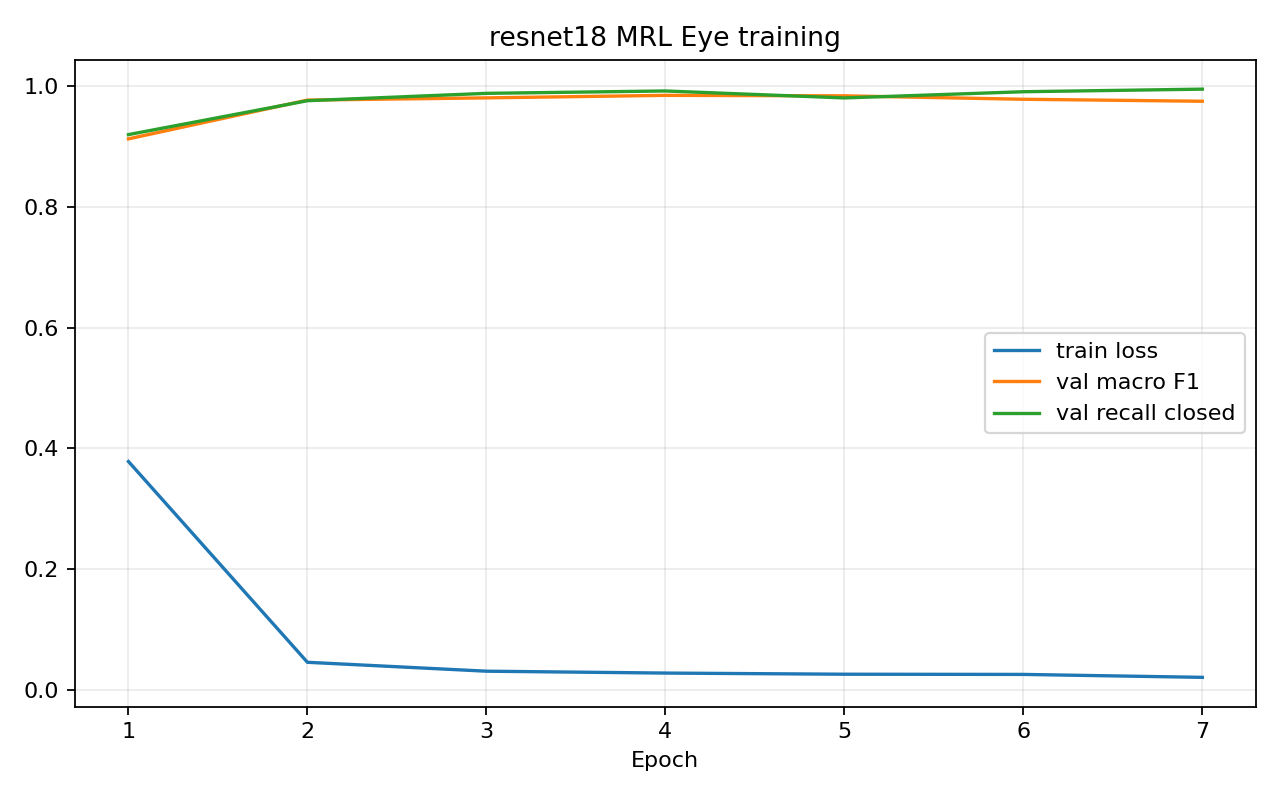

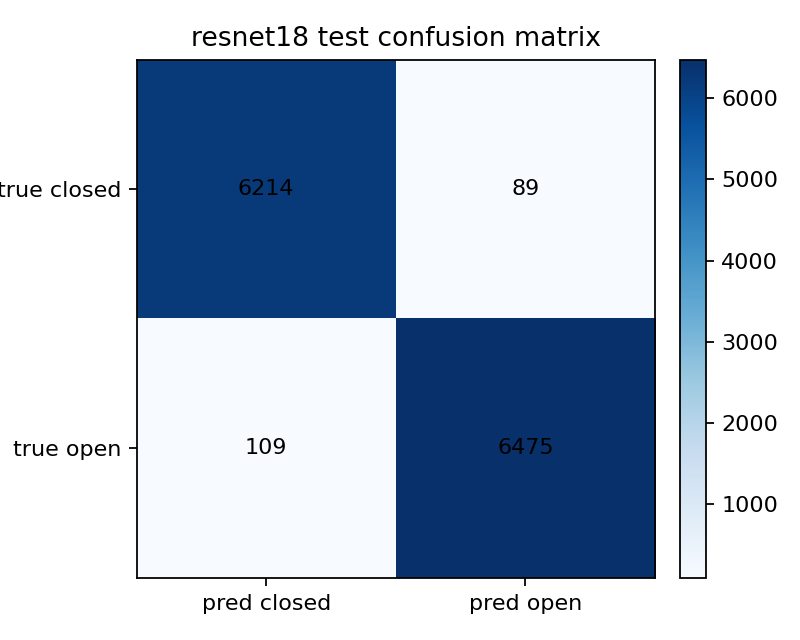


 mobilenet_v2


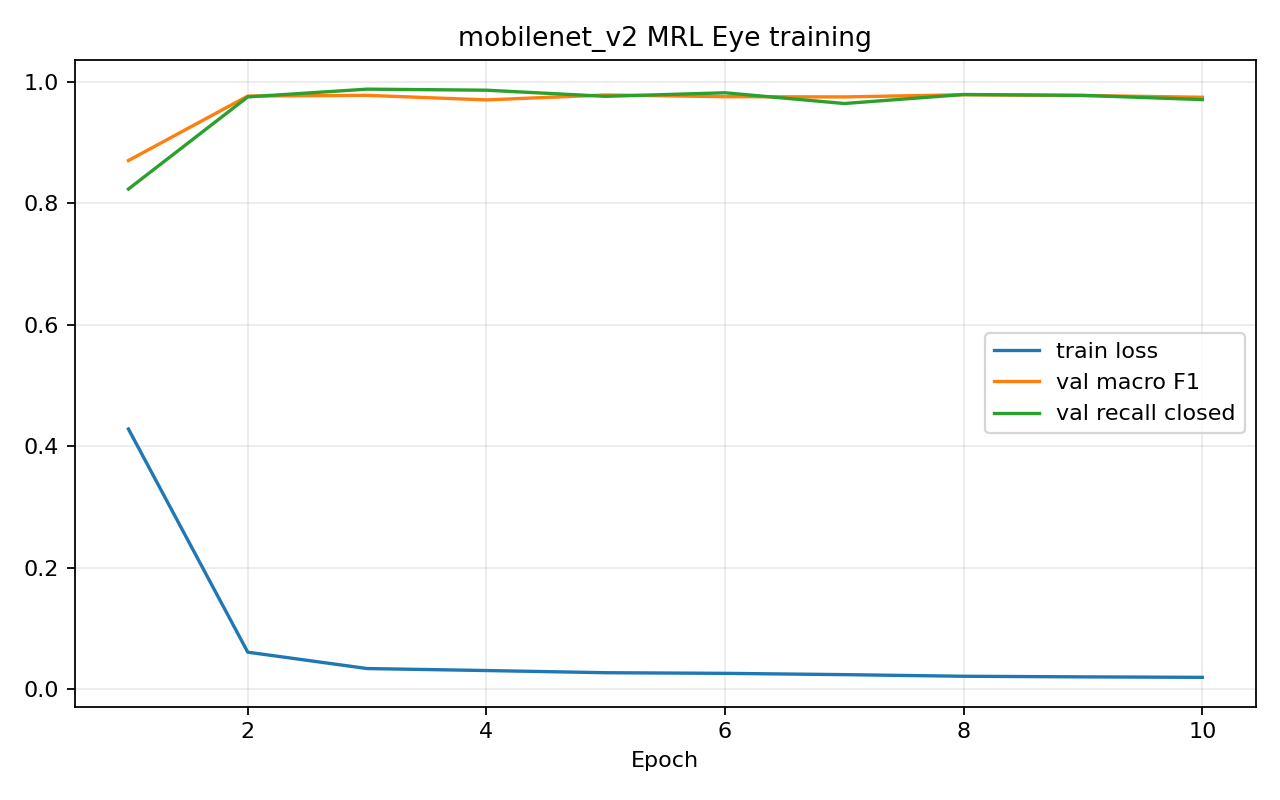

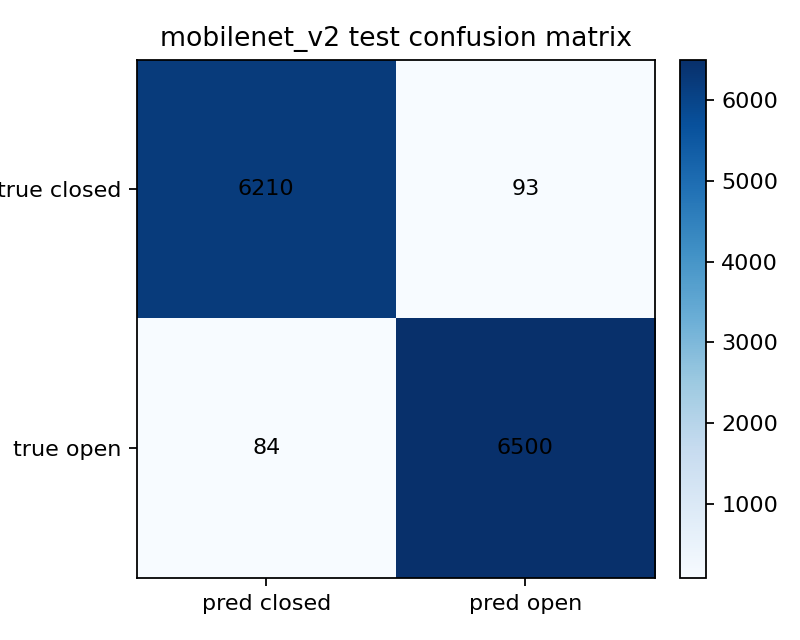


 efficientnet_b0


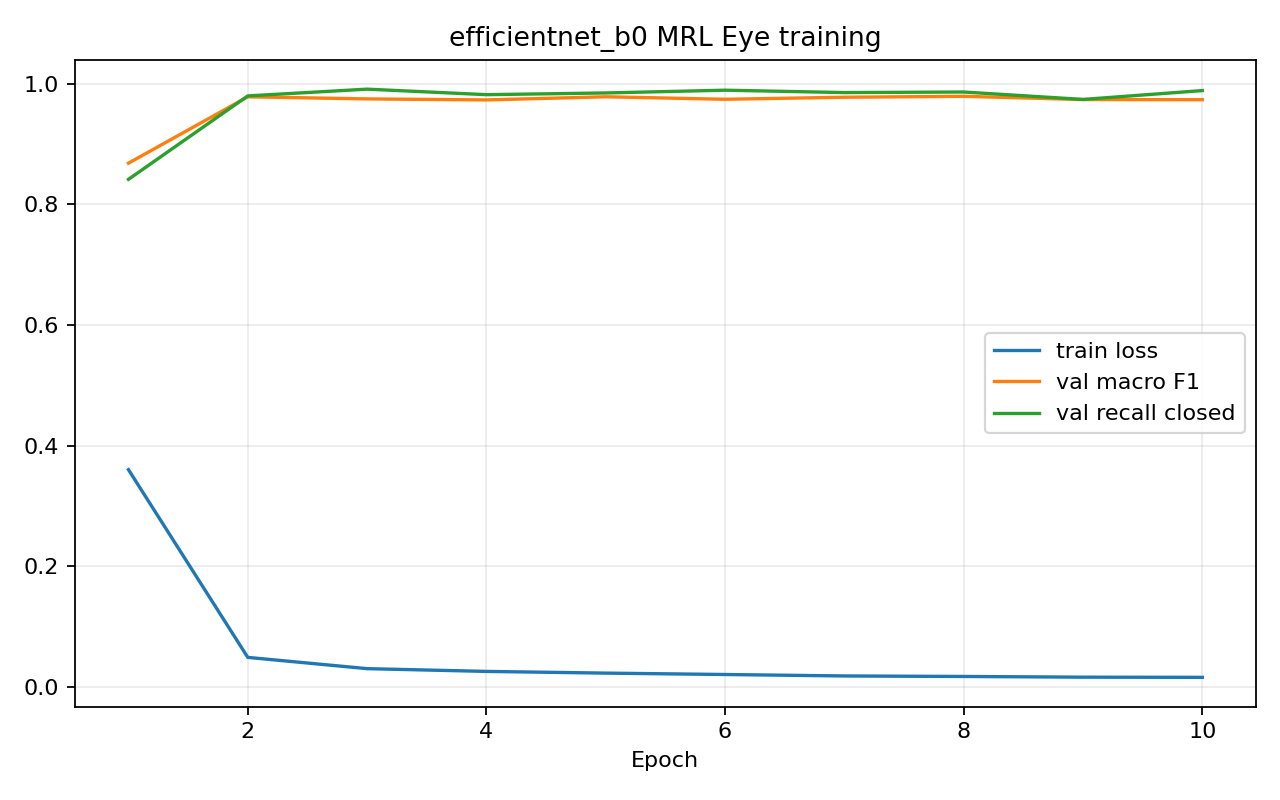

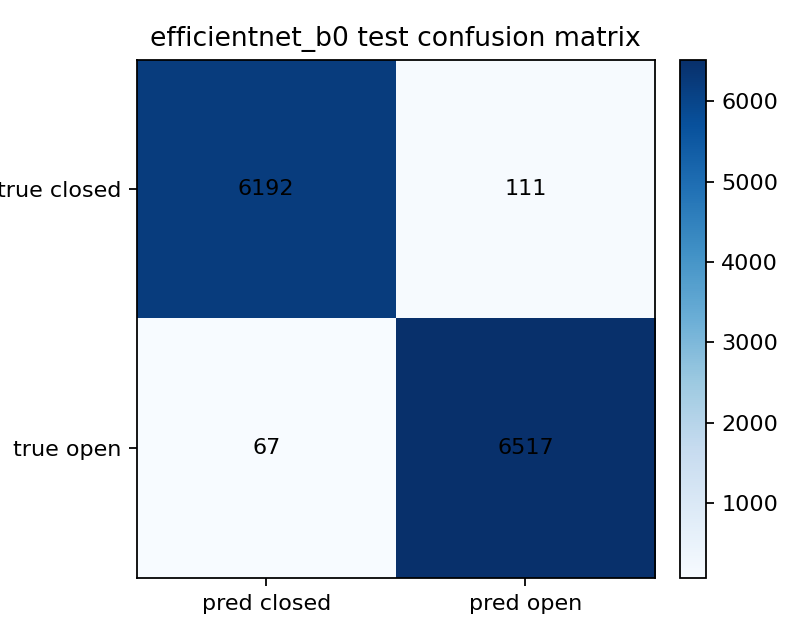

In [12]:
# 12. Display confusion matrices and training curves
from IPython.display import Image as IPyImage, display

for model_name in MODELS:
    print("\n", model_name)
    curve = Path(OUTPUT_DIR_STR) / "figures" / f"{model_name}_training_curve.png"
    cm = Path(OUTPUT_DIR_STR) / "figures" / f"{model_name}_confusion_matrix.png"
    if curve.exists():
        display(IPyImage(filename=str(curve)))
    if cm.exists():
        display(IPyImage(filename=str(cm)))


In [13]:
# 13. Inspect threshold sweeps for p_eye_closed
for model_name in MODELS:
    for split_name in ["val", "test"]:
        sweep_path = Path(OUTPUT_DIR_STR) / "results" / f"{model_name}_{split_name}_threshold_sweep.csv"
        if sweep_path.exists():
            print("\n", model_name, split_name)
            display(pd.read_csv(sweep_path))



 resnet18 val


,threshold,accuracy,macro_f1,precision_closed,recall_closed,f1_closed,precision_open,recall_open,f1_open,false_open_count,false_closed_count
0,0.30,0.979200,0.979197,0.963172,0.995263,0.978955,0.995374,0.964008,0.979440,30,241
1,0.35,0.980582,0.980578,0.966830,0.994158,0.980304,0.994323,0.967742,0.980852,37,216
2,0.40,0.982040,0.982035,0.970529,0.993210,0.981739,0.993433,0.971476,0.982332,43,191
3,0.45,0.983115,0.983109,0.973656,0.992105,0.982794,0.992397,0.974612,0.983424,50,170
4,0.50,0.983729,0.983722,0.975898,0.991000,0.983391,0.991361,0.976852,0.984053,57,155
5,0.55,0.984803,0.984795,0.979822,0.989105,0.984441,0.989602,0.980735,0.985149,69,129
6,0.60,0.984880,0.984870,0.982390,0.986578,0.984480,0.987254,0.983274,0.985260,85,112
7,0.65,0.984957,0.984945,0.984373,0.984683,0.984528,0.985509,0.985215,0.985362,97,99
8,0.70,0.984496,0.984482,0.986510,0.981525,0.984011,0.982610,0.987306,0.984952,117,85



 resnet18 test


,threshold,accuracy,macro_f1,precision_closed,recall_closed,f1_closed,precision_open,recall_open,f1_open,false_open_count,false_closed_count
0,0.30,0.976022,0.976021,0.961361,0.990798,0.975857,0.990925,0.961877,0.976185,58,251
1,0.35,0.978195,0.978192,0.967401,0.988736,0.977952,0.988984,0.968104,0.978433,71,210
2,0.40,0.980523,0.980519,0.972517,0.988101,0.980247,0.988431,0.973269,0.980791,75,176
3,0.45,0.982773,0.982768,0.977991,0.986990,0.982470,0.987435,0.978736,0.983066,82,140
4,0.50,0.984636,0.984629,0.982761,0.985880,0.984318,0.986441,0.983445,0.984941,89,109
5,0.55,0.985800,0.985792,0.986332,0.984611,0.985470,0.985292,0.986938,0.986114,97,86
6,0.60,0.985489,0.985480,0.988498,0.981755,0.985115,0.982647,0.989064,0.985845,115,72
7,0.65,0.985412,0.985401,0.990692,0.979375,0.985001,0.980469,0.991191,0.985801,130,58
8,0.70,0.986032,0.986021,0.993075,0.978264,0.985614,0.979485,0.993469,0.986427,137,43



 mobilenet_v2 val


...

,threshold,accuracy,macro_f1,precision_closed,recall_closed,f1_closed,precision_open,recall_open,f1_open,false_open_count,false_closed_count
0,0.30,0.984791,0.984786,0.981093,0.987942,0.984506,0.988379,0.981774,0.985066,76,120
1,0.35,0.985024,0.985018,0.982165,0.987308,0.984730,0.987788,0.982837,0.985306,80,113
2,0.40,0.986110,0.986104,0.984801,0.986832,0.985815,0.987369,0.985419,0.986393,83,96
3,0.45,0.985877,0.985870,0.985717,0.985404,0.985560,0.986031,0.986330,0.986181,92,90
4,0.50,0.986265,0.986258,0.986654,0.985245,0.985949,0.985894,0.987242,0.986568,93,84
5,0.55,0.986420,0.986413,0.988209,0.983976,0.986088,0.984722,0.988761,0.986737,101,74
6,0.60,0.985877,0.985868,0.989289,0.981755,0.985507,0.982660,0.989824,0.986229,115,67
7,0.65,0.985800,0.985790,0.990070,0.980803,0.985415,0.981785,0.990583,0.986165,121,62
8,0.70,0.985256,0.985245,0.991004,0.978740,0.984834,0.979886,0.991495,0.985656,134,56



 efficientnet_b0 val


,threshold,accuracy,macro_f1,precision_closed,recall_closed,f1_closed,precision_open,recall_open,f1_open,false_open_count,false_closed_count
0,0.30,0.975746,0.975742,0.960932,0.990368,0.975428,0.990618,0.961918,0.976057,61,255
1,0.35,0.976667,0.976662,0.963698,0.989263,0.976313,0.989583,0.964755,0.977011,68,236
2,0.40,0.977972,0.977966,0.966800,0.988631,0.977594,0.989013,0.967891,0.978338,72,215
3,0.45,0.978356,0.978348,0.968852,0.987210,0.977945,0.987682,0.969982,0.978752,81,201
4,0.50,0.979123,0.979115,0.971233,0.986262,0.978690,0.986814,0.972372,0.979540,87,185
5,0.55,0.978970,0.978960,0.972842,0.984210,0.978493,0.984899,0.974014,0.979426,100,174
6,0.60,0.979354,0.979342,0.975086,0.982631,0.978844,0.983451,0.976254,0.979840,110,159
7,0.65,0.978663,0.978648,0.976847,0.979315,0.978079,0.980389,0.978047,0.979217,131,147
8,0.70,0.978663,0.978645,0.979262,0.976788,0.978024,0.978099,0.980436,0.979266,147,131



 efficientnet_b0 test


,threshold,accuracy,macro_f1,precision_closed,recall_closed,f1_closed,precision_open,recall_open,f1_open,false_open_count,false_closed_count
0,0.30,0.985179,0.985173,0.983238,0.986514,0.984874,0.987049,0.983900,0.985472,85,106
1,0.35,0.985256,0.985249,0.984928,0.984928,0.984928,0.985571,0.985571,0.985571,95,95
2,0.40,0.985800,0.985792,0.986641,0.984293,0.985466,0.984998,0.987242,0.986118,99,84
3,0.45,0.986110,0.986102,0.988046,0.983500,0.985768,0.984273,0.988609,0.986436,104,75
4,0.50,0.986188,0.986179,0.989295,0.982389,0.985830,0.983253,0.989824,0.986527,111,67
5,0.55,0.986498,0.986489,0.990713,0.981596,0.986133,0.982535,0.991191,0.986844,116,58
6,0.60,0.986420,0.986410,0.991656,0.980485,0.986039,0.981518,0.992102,0.986781,123,52
7,0.65,0.986188,0.986177,0.992443,0.979216,0.985785,0.980354,0.992861,0.986568,131,47
8,0.70,0.985955,0.985943,0.993391,0.977788,0.985528,0.979051,0.993773,0.986357,140,41


## Interpretation Notes

- Prioritize validation macro F1 for checkpoint selection.
- Review closed-eye recall carefully. False-open errors are true closed-eye frames predicted as open, which can hide eye-closure events.
- Do not choose a threshold that predicts nearly everything as closed. Use the threshold sweep to balance closed recall with macro F1 and false-closed errors.
- The next stage should use `p_eye_closed` over time for smoothing or PERCLOS-like logic, then fuse with YawDD mouth/yawn outputs.